In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from joblib import Parallel, delayed


In [2]:
import itertools

# Parameters
resol = 250000
intra_norm = 'SCALE'
inter_norm = 'GWSCALE'
chr_list = np.arange(1, 22 + 1, 1)
chr_pairs_inter = list(itertools.combinations(chr_list, 2))
chr_pairs_intra = [(chrom, chrom) for chrom in chr_list]

# Compare Hi-C binding in IMR90

## Load data

### ncRNA data

In [3]:
import ast

# ncRNA transcription sites and binding sites
ncrna_df = pd.read_csv('../data/imr90/imr90_specific_ncrna_dna_bs_data_all_expressed.csv.gz',
                       header=0, index_col=None)
ncrna_df = ncrna_df[
    ['ncID_ensembl', 'ia_loci']
]
ncrna_df.loc[:, 'ia_loci'] = ncrna_df['ia_loci'].apply(ast.literal_eval)
ncrna_df = ncrna_df.groupby('ncID_ensembl')['ia_loci'].agg(sum)
ncrna_df = ncrna_df.to_frame()

/tmp/ipykernel_3813272/3279738445.py:10: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ncrna_df = ncrna_df.groupby('ncID_ensembl')['ia_loci'].agg(sum)


In [4]:
from collections import defaultdict

# Create dictionary of bound loci for each ncRNA
locus_dict_list = []
for ncrna_id in ncrna_df.index:
    locus_dict = defaultdict(list)
    for loc in ncrna_df.loc[ncrna_id, 'ia_loci']:
        chrom = int(loc.split('_')[0][3:])
        locus_dict[chrom].append(loc)
    locus_dict_list.append(locus_dict)
ncrna_df.loc[:, 'locus_dict'] = locus_dict_list
print(f'Total number of ncRNAs = {ncrna_df.index.nunique()}')
ncrna_df.head()

Total number of ncRNAs = 1888


,ia_loci,locus_dict
ncID_ensembl,,
ENSG00000093100,"[chr1_loc_11000000, chr1_loc_11750000, chr1_lo...","{1: ['chr1_loc_11000000', 'chr1_loc_11750000',..."
ENSG00000103472,"[chr1_loc_210000000, chr11_loc_9500000, chr11_...","{1: ['chr1_loc_210000000'], 11: ['chr11_loc_95..."
ENSG00000116652,"[chr1_loc_7250000, chr1_loc_7500000, chr1_loc_...","{1: ['chr1_loc_7250000', 'chr1_loc_7500000', '..."
ENSG00000117242,"[chr1_loc_7500000, chr1_loc_12250000, chr1_loc...","{1: ['chr1_loc_7500000', 'chr1_loc_12250000', ..."
ENSG00000120664,"[chr1_loc_41500000, chr1_loc_99250000, chr1_lo...","{1: ['chr1_loc_41500000', 'chr1_loc_99250000',..."


In [5]:
import itertools

chr_list = np.arange(1, 22 + 1, 1)

# Create dictionary matching each chromosome to the list of its loci that are bound by at least one ncRNA
all_chr_loci_dict = {}
for chrom in chr_list:
    all_chr_loc = [ncrna_df.loc[ncrna_id0, 'locus_dict'][chrom] for ncrna_id0 in ncrna_df.index]
    all_chr_loc = itertools.chain.from_iterable(all_chr_loc)
    all_chr_loc = set(all_chr_loc)
    all_chr_loc = sorted([int(loc.split('_')[2]) for loc in all_chr_loc])
    all_chr_loci_dict[chrom] = all_chr_loc

### Hi-C data

In [6]:
import pickle


# Load blacklisted loci in Hi-C
blacklist_fname = '../data/imr90/hic/preprocessed/normalized_hic/'+f'blacklisted_loci_{inter_norm}.pickle'
with open(blacklist_fname, 'rb') as f:
    blacklisted_loci = pickle.load(f)
blacklist_dict = {
    c: [int(loc.split('_')[3]) for loc in blacklisted_loci if int(loc.split('_')[1])==c] 
    for c in np.arange(1, 22+1, 1)
}

# Compare interchromosmal proximity of loci bound by the same ncRNAs vs random loci

## Retreive Hi-C contacts among ncRNA binding loci

In [7]:
# Create data frame to store results
hic_results = {ncrna_id: [] for ncrna_id in ncrna_df.index}

In [8]:
# Function to retrieve Hi-C values among binding loci of each ncRNA
def retrieve_hic_values(
    ncrna_id, ncrna_df, chr1, chr2, hic_filtered_df, blacklist_dict, seed
):
    # Identify blacklisted loci on chr1 and chr2
    blacklisted_chr1_loc = blacklist_dict[chr1]
    blacklisted_chr2_loc = blacklist_dict[chr2]

    # Hi-C values corresponding to ncRNA binding sites loci
    chr1_loc = ncrna_df.loc[ncrna_id, "locus_dict"][chr1]
    chr1_loc = [int(loc.split('_')[2]) for loc in chr1_loc]
    chr1_loc = list(set(chr1_loc) - set(blacklisted_chr1_loc))
    chr2_loc = ncrna_df.loc[ncrna_id, "locus_dict"][chr2]
    chr2_loc = [int(loc.split('_')[2]) for loc in chr2_loc]
    chr2_loc = list(set(chr2_loc) - set(blacklisted_chr2_loc))
    hic_vals = hic_filtered_df.loc[chr1_loc, chr2_loc].values.flatten().tolist()
    hic_results[ncrna_id].extend(hic_vals)

In [9]:
dir_preprocessed_hic = "../data/imr90/hic/preprocessed/normalized_hic/"
# Populate hic_results with Hi-C contact values
seed = 13
for chr1, chr2 in tqdm(chr_pairs_inter):
    norm = intra_norm if (chr1 == chr2) else inter_norm
    filtered_hic_filename = dir_preprocessed_hic + f"hic_chr{chr1}_chr{chr2}_filtered_{norm}.csv"
    hic_filtered_df = pd.read_csv(filtered_hic_filename, header=0, index_col=0)
    hic_filtered_df.columns = hic_filtered_df.columns.astype(int)
    Parallel(n_jobs=os.cpu_count()-5, require="sharedmem")(delayed(retrieve_hic_values)(
            ncrna_id,
            ncrna_df,
            chr1,
            chr2,
            hic_filtered_df,
            blacklist_dict,
            seed
        )
        for ncrna_id in ncrna_df.index
    )

100%|████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [03:23<00:00,  1.13it/s]


## Retrieve Hi-C contacts among random loci

In [10]:
# Create data frame to store results
hic_random = {ncrna_id: [] for ncrna_id in ncrna_df.index}

In [11]:
# Function to retrieve Hi-C values among binding loci of each ncRNA
def retrieve_hic_random(
    ncrna_id, ncrna_df, chr1, chr2, hic_filtered_df, blacklist_dict, seed
):
    # Identify blacklisted loci on chr1 and chr2
    blacklisted_chr1_loc = blacklist_dict[chr1]
    blacklisted_chr2_loc = blacklist_dict[chr2]
    
    # Identify ncRNA binding sites loci on chr1 and chr2
    chr1_loc = ncrna_df.loc[ncrna_id, "locus_dict"][chr1]
    chr1_loc = [int(loc.split('_')[2]) for loc in chr1_loc]
    chr1_loc = list(set(chr1_loc) - set(blacklisted_chr1_loc))
    chr2_loc = ncrna_df.loc[ncrna_id, "locus_dict"][chr2]
    chr2_loc = [int(loc.split('_')[2]) for loc in chr2_loc]
    chr2_loc = list(set(chr2_loc) - set(blacklisted_chr2_loc))
    
    # Select random loci on chr1 and chr2 different from the above loci
    all_chr1_loc = hic_filtered_df.index.values
    chr1_loc_pool = list(set(all_chr1_loc) - set(chr1_loc) - set(blacklisted_chr1_loc))
    chr1_random_loc = np.random.choice(chr1_loc_pool, len(chr1_loc), replace=True)
    all_chr2_loc = hic_filtered_df.columns.values
    chr2_loc_pool = list(set(all_chr2_loc) - set(chr2_loc) - set(blacklisted_chr2_loc))
    chr2_random_loc = np.random.choice(chr2_loc_pool, len(chr2_loc), replace=True)
    
    # Hi-C values corresponding to these random loci
    hic_vals = hic_filtered_df.loc[chr1_random_loc, chr2_random_loc].values.flatten().tolist()
    hic_random[ncrna_id].extend(hic_vals)

In [12]:
# Populate hic_random with Hi-C contact values
seed = 13
for chr1, chr2 in tqdm(chr_pairs_inter):
    norm = intra_norm if (chr1 == chr2) else inter_norm
    filtered_hic_filename = dir_preprocessed_hic + f"hic_chr{chr1}_chr{chr2}_filtered_{norm}.csv"
    hic_filtered_df = pd.read_csv(filtered_hic_filename, header=0, index_col=0)
    hic_filtered_df.columns = hic_filtered_df.columns.astype(int)
    Parallel(n_jobs=os.cpu_count()-5, require="sharedmem")(delayed(retrieve_hic_random)(
            ncrna_id,
            ncrna_df,
            chr1,
            chr2,
            hic_filtered_df,
            blacklist_dict,
            seed
        )
        for ncrna_id in ncrna_df.index
    )

100%|████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [06:02<00:00,  1.57s/it]


## Retrieve Hi-C contacts among loci bound by random ncRNAs

In [13]:
# Create data frame to store results
hic_random_ncrna = {ncrna_id: [] for ncrna_id in ncrna_df.index}

# Function to retrieve Hi-C values among binding loci of each ncRNA
def retrieve_hic_randomncrna(
    ncrna_id, ncrna_df, chr1, chr2, hic_filtered_df, blacklist_dict, all_chr_loci_dict, seed
):
    # Identify blacklisted loci on chr1 and chr2
    blacklisted_chr1_loc = blacklist_dict[chr1]
    blacklisted_chr2_loc = blacklist_dict[chr2]
    
    # Identify ncRNA binding sites loci on chr1 and chr2
    chr1_loc = ncrna_df.loc[ncrna_id, "locus_dict"][chr1]
    chr1_loc = [int(loc.split('_')[2]) for loc in chr1_loc]
    chr1_loc = list(set(chr1_loc) - set(blacklisted_chr1_loc))
    chr2_loc = ncrna_df.loc[ncrna_id, "locus_dict"][chr2]
    chr2_loc = [int(loc.split('_')[2]) for loc in chr2_loc]
    chr2_loc = list(set(chr2_loc) - set(blacklisted_chr2_loc))
    
    # Select random loci on chr1 and chr2 different from the above loci
    all_chr1_loc = all_chr_loci_dict[chr1]
    chr1_loc_pool = list(set(all_chr1_loc) - set(chr1_loc) - set(blacklisted_chr1_loc))
    chr1_random_loc = np.random.choice(chr1_loc_pool, len(chr1_loc), replace=True)
    all_chr2_loc = all_chr_loci_dict[chr2]
    chr2_loc_pool = list(set(all_chr2_loc) - set(chr2_loc) - set(blacklisted_chr2_loc))
    chr2_random_loc = np.random.choice(chr2_loc_pool, len(chr2_loc), replace=True)
    
    # Hi-C values corresponding to these random loci
    hic_vals = hic_filtered_df.loc[chr1_random_loc, chr2_random_loc].values.flatten().tolist()
    hic_random_ncrna[ncrna_id].extend(hic_vals)

In [14]:
# Populate hic_random with Hi-C contact values
seed = 13
for chr1, chr2 in tqdm(chr_pairs_inter):
    norm = intra_norm if (chr1 == chr2) else inter_norm
    filtered_hic_filename = dir_preprocessed_hic + f"hic_chr{chr1}_chr{chr2}_filtered_{norm}.csv"
    hic_filtered_df = pd.read_csv(filtered_hic_filename, header=0, index_col=0)
    hic_filtered_df.columns = hic_filtered_df.columns.astype(int)
    Parallel(n_jobs=os.cpu_count()-5, require="sharedmem")(delayed(retrieve_hic_randomncrna)(
            ncrna_id,
            ncrna_df,
            chr1,
            chr2,
            hic_filtered_df,
            blacklist_dict,
            all_chr_loci_dict,
            seed
        )
        for ncrna_id in ncrna_df.index
    )

100%|████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [05:15<00:00,  1.37s/it]


In [15]:
import scipy.stats as ss

# Compare BS and random at the aggregated level
x_inter = np.array(list(itertools.chain.from_iterable(list(hic_results.values()))))
y_inter = np.array(list(itertools.chain.from_iterable(list(hic_random.values()))))
z_inter = np.array(list(itertools.chain.from_iterable(list(hic_random_ncrna.values()))))

stat, pval = ss.ranksums(x_inter, y_inter)
print(f"Wilcoxon Ranks Sum statistic = {stat}")
print(f"Wilcoxon Ranks Sum p-value = {pval}")

Wilcoxon Ranks Sum statistic = 1993.1757607370641
Wilcoxon Ranks Sum p-value = 0.0


## Fig S7a

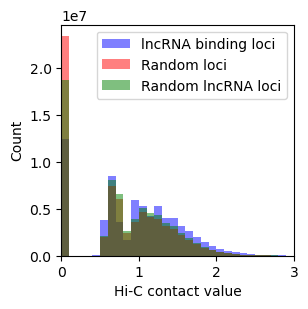

In [24]:
# Visualize BS and random contact distributions as histograms

# Optional: subsample to plot faster
np.random.seed(13)
# index_subset = np.random.choice(len(x_inter), size=1000, replace=True) 
index_subset = np.arange(len(x_inter))

plt.figure(figsize=(3,3))
plt.hist(
    x_inter[index_subset],
    bins=np.arange(0, 4, 0.1),
    color="blue",
    alpha=0.5,
    label="lncRNA binding loci",
)
plt.hist(
    y_inter[index_subset],
    bins=np.arange(0, 4, 0.1),
    color="red",
    alpha=0.5,
    label="Random loci",
)
plt.hist(
    z_inter[index_subset],
    bins=np.arange(0, 4, 0.1),
    color="green",
    alpha=0.5,
    label="Random lncRNA loci",
)
plt.xlim(0, 3)
plt.xlabel("Hi-C contact value")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.show()

## Fig 2a

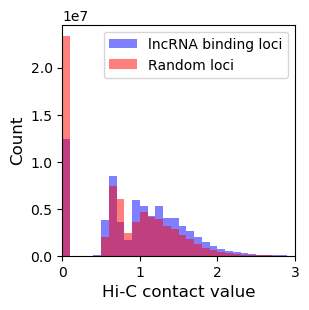

In [39]:
# Visualize BS and random contact distributions as histograms

# Optional: subsample to plot faster
np.random.seed(13)
# index_subset = np.random.choice(len(x_inter), size=1000, replace=True) 
index_subset = np.arange(len(x_inter))

plt.figure(figsize=(3,3))
plt.hist(
    x_inter[index_subset],
    bins=np.arange(0, 4, 0.1),
    color="blue",
    alpha=0.5,
    label="lncRNA binding loci",
)
plt.hist(
    y_inter[index_subset],
    bins=np.arange(0, 4, 0.1),
    color="red",
    alpha=0.5,
    label="Random loci",
)
plt.xlim(0, 3)
plt.xlabel("Hi-C contact value", fontsize = 12)
plt.ylabel("Count", fontsize = 12)
plt.legend(loc="upper right", fontsize = 10)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()


# Compare INTRAchromosmal proximity of loci bound by the same ncRNAs vs random loci

## Retrieve Hi-C contacts among ncRNA binding loci

In [40]:
# Create data frame to store results
hic_results = {ncrna_id: [] for ncrna_id in ncrna_df.index}

# Populate hic_results with Hi-C contact values
seed = 13
for chr1, chr2 in tqdm(chr_pairs_intra):
    norm = intra_norm if (chr1 == chr2) else inter_norm
    filtered_hic_filename = dir_preprocessed_hic + f"hic_chr{chr1}_chr{chr2}_filtered_{norm}.csv"
    hic_filtered_df = pd.read_csv(filtered_hic_filename, header=0, index_col=0)
    hic_filtered_df.columns = hic_filtered_df.columns.astype(int)
    Parallel(n_jobs=os.cpu_count()-5, require="sharedmem")(delayed(retrieve_hic_values)(
            ncrna_id,
            ncrna_df,
            chr1,
            chr2,
            hic_filtered_df,
            blacklist_dict,
            seed
        )
        for ncrna_id in ncrna_df.index
    )

100%|███████████████████████████████████████████████████████████████████████████████| 22/22 [00:20<00:00,  1.09it/s]


## Retrieve Hi-C contacts among random loci

In [41]:
# Create data frame to store results
hic_random = {ncrna_id: [] for ncrna_id in ncrna_df.index}

# Populate hic_random with Hi-C contact values
seed = 13
for chr1, chr2 in tqdm(chr_pairs_intra):
    norm = intra_norm if (chr1 == chr2) else inter_norm
    filtered_hic_filename = dir_preprocessed_hic + f"hic_chr{chr1}_chr{chr2}_filtered_{norm}.csv"
    hic_filtered_df = pd.read_csv(filtered_hic_filename, header=0, index_col=0)
    hic_filtered_df.columns = hic_filtered_df.columns.astype(int)
    Parallel(n_jobs=32, require="sharedmem")(delayed(retrieve_hic_random)(
            ncrna_id,
            ncrna_df,
            chr1,
            chr2,
            hic_filtered_df,
            blacklist_dict,
            seed
        )
        for ncrna_id in ncrna_df.index
    )

100%|███████████████████████████████████████████████████████████████████████████████| 22/22 [00:34<00:00,  1.55s/it]


## Retrieve Hi-C contacts among loci bound by random ncRNAs

In [42]:
# Create data frame to store results
hic_random_ncrna = {ncrna_id: [] for ncrna_id in ncrna_df.index}

# Populate hic_random with Hi-C contact values
seed = 13
for chr1, chr2 in tqdm(chr_pairs_intra):
    norm = intra_norm if (chr1 == chr2) else inter_norm
    filtered_hic_filename = dir_preprocessed_hic + f"hic_chr{chr1}_chr{chr2}_filtered_{norm}.csv"
    hic_filtered_df = pd.read_csv(filtered_hic_filename, header=0, index_col=0)
    hic_filtered_df.columns = hic_filtered_df.columns.astype(int)
    Parallel(n_jobs=32, require="sharedmem")(delayed(retrieve_hic_randomncrna)(
            ncrna_id,
            ncrna_df,
            chr1,
            chr2,
            hic_filtered_df,
            blacklist_dict,
            all_chr_loci_dict,
            seed
        )
        for ncrna_id in ncrna_df.index
    )

100%|███████████████████████████████████████████████████████████████████████████████| 22/22 [00:28<00:00,  1.31s/it]


## Compare Hi-C distributions

In [43]:
# Compare BS and random at the aggregated level
x_intra = np.array(list(itertools.chain.from_iterable(list(hic_results.values()))))
y_intra = np.array(list(itertools.chain.from_iterable(list(hic_random.values()))))
z_intra = np.array(list(itertools.chain.from_iterable(list(hic_random_ncrna.values()))))

stat, pval = ss.ranksums(x_intra, y_intra)
print(f"Wilcoxon Ranks Sum statistic = {stat}")
print(f"Wilcoxon Ranks Sum p-value = {pval}")

Wilcoxon Ranks Sum statistic = 533.7907559317104
Wilcoxon Ranks Sum p-value = 0.0


### Fig S7b

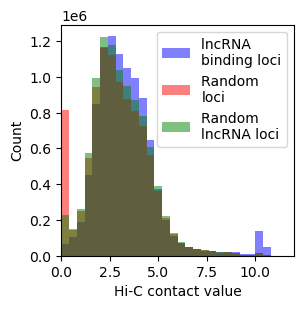

In [45]:
# Visualize BS and random contact distributions as histograms

# Optional: subsample to plot faster
np.random.seed(13)
# index_subset = np.random.choice(len(x_intra), size=100000, replace=True) 
index_subset = np.arange(len(x_intra))

plt.figure(figsize=(3,3))
plt.hist(
    x_intra[index_subset],
    bins=np.arange(0, 12, 0.4),
    color="blue",
    alpha=0.5,
    label="lncRNA \nbinding loci",
)
plt.hist(
    y_intra[index_subset],
    bins=np.arange(0, 12, 0.4),
    color="red",
    alpha=0.5,
    label="Random \nloci",
)
plt.hist(
    z_intra[index_subset],
    bins=np.arange(0, 12, 0.4),
    color="green",
    alpha=0.5,
    label="Random \nlncRNA loci",
)
plt.xlim(0, 12)
plt.xlabel("Hi-C contact value")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.show()

### Fig 2b

(array([      0.,  200000.,  400000.,  600000.,  800000., 1000000.,
        1200000., 1400000.]),
 [Text(0, 0.0, '0.0'),
  Text(0, 200000.0, '0.2'),
  Text(0, 400000.0, '0.4'),
  Text(0, 600000.0, '0.6'),
  Text(0, 800000.0, '0.8'),
  Text(0, 1000000.0, '1.0'),
  Text(0, 1200000.0, '1.2'),
  Text(0, 1400000.0, '1.4')])

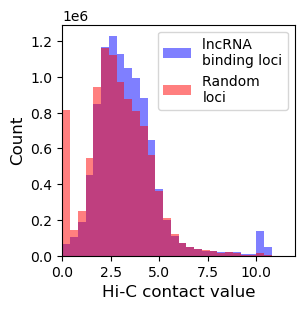

In [44]:
# Visualize BS and random contact distributions as histograms

# Optional: subsample to plot faster
np.random.seed(13)
# index_subset = np.random.choice(len(x_intra), size=100000, replace=True) 
index_subset = np.arange(len(x_intra))

plt.figure(figsize=(3,3))
plt.hist(
    x_intra[index_subset],
    bins=np.arange(0, 12, 0.4),
    color="blue",
    alpha=0.5,
    label="lncRNA \nbinding loci",
)
plt.hist(
    y_intra[index_subset],
    bins=np.arange(0, 12, 0.4),
    color="red",
    alpha=0.5,
    label="Random \nloci",
)
plt.xlim(0, 12)
plt.xlabel("Hi-C contact value", fontsize = 12)
plt.ylabel("Count", fontsize = 12)
plt.legend(loc="upper right", fontsize = 10)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
